# 02 - Análise exploratória e seleção de variáveis

A EDA primeiro examina a Gold completa. Só depois identifica leakage e constrói o recorte de nove colunas usado pelo projeto de referência.

**Unidade de análise:** município-ano da rede municipal. Como não há microdados por aluno, alvo_alfabetizado é uma **proxy municipal**: 1 quando a taxa observada atingiu a meta municipal de 2025 e 0 caso contrário.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import ler_particionado
from src.preprocessing.config import LAKE_DIR
from src.preprocessing.build_features import salvar_dataset_modelagem

sns.set_theme(style="whitegrid")
gold = ler_particionado(LAKE_DIR / "gold" / "alfabetizacao_por_municipio")
indicador = ler_particionado(LAKE_DIR / "silver" / "pass" / "indicador_municipio")
print(gold.shape)
gold.info()

(10896, 12)
<class 'pandas.DataFrame'>
RangeIndex: 10896 entries, 0 to 10895
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_municipio         10896 non-null  string 
 1   serie                10896 non-null  Int64  
 2   rede                 10896 non-null  str    
 3   taxa_alfabetizacao   10896 non-null  float64
 4   media_portugues      10896 non-null  float64
 5   meta_2025            10654 non-null  float64
 6   meta_2030            10654 non-null  float64
 7   nivel_alfabetizacao  10584 non-null  string 
 8   gap_meta_2025        10654 non-null  float64
 9   status_meta_2025     10654 non-null  str    
 10  _gold_processed_at   10896 non-null  str    
 11  ano                  10896 non-null  int64  
dtypes: Int64(1), float64(5), int64(1), str(3), string(2)
memory usage: 1.6 MB


## Distribuição do indicador e da proxy

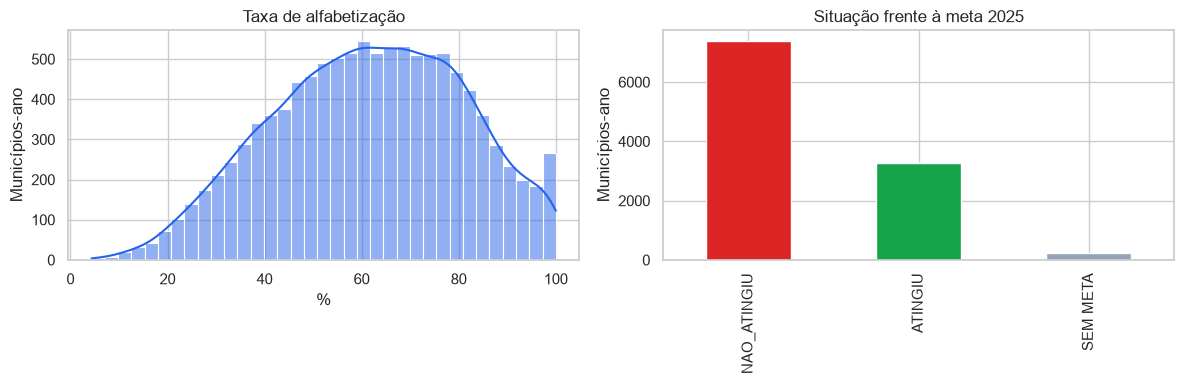

,count,mean,std,min,25%,50%,75%,max
ano,,,,,,,,
2023,5448.0,60.28,19.82,4.35,46.50,60.72,75.00,100.0
2024,5448.0,62.80,19.34,4.40,48.28,64.05,77.59,100.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(gold["taxa_alfabetizacao"], bins=35, kde=True, ax=axes[0], color="#2563eb")
axes[0].set(title="Taxa de alfabetização", xlabel="%", ylabel="Municípios-ano")
status = gold["status_meta_2025"].fillna("SEM META").value_counts()
status.plot.bar(ax=axes[1], color=["#dc2626", "#16a34a", "#94a3b8"])
axes[1].set(title="Situação frente à meta 2025", xlabel="", ylabel="Municípios-ano")
plt.tight_layout()
plt.show()
display(gold.groupby("ano")["taxa_alfabetizacao"].describe().round(2))

## Diagnóstico de data leakage

O alvo é função de taxa_alfabetizacao e meta_2025. Por isso, taxa, gap, status e nível nunca podem entrar em X. As proporções dos níveis SAEB são outra representação da mesma avaliação e também são excluídas. A pipeline de dados continua intacta: a exclusão ocorre apenas na preparação analítica.

In [3]:
municipal = indicador[indicador["rede"] == "3"].copy()
municipal["soma_niveis_5_8"] = municipal[
    [f"proporcao_aluno_nivel_{i}" for i in range(5, 9)]
].sum(axis=1)
display(municipal[
    ["taxa_alfabetizacao", "media_portugues", "soma_niveis_5_8"]
].corr().round(3))
checagem = gold.dropna(subset=["status_meta_2025"]).copy()
checagem["alvo"] = (checagem["status_meta_2025"] == "ATINGIU").astype(int)
print("Correlação taxa x alvo:",
      round(checagem[["taxa_alfabetizacao", "alvo"]].corr().iloc[0, 1], 3))

,taxa_alfabetizacao,media_portugues,soma_niveis_5_8
taxa_alfabetizacao,1.000,0.927,0.364
media_portugues,0.927,1.000,0.331
soma_niveis_5_8,0.364,0.331,1.000


Correlação taxa x alvo: 0.648


### Variáveis mantidas, seguindo a referência

- Numéricas: media_portugues, meta_2025, meta_uf_2025 e taxa_media_uf_loo.
- Categóricas: sigla_uf e regiao.
- Identificação: id_municipio e ano.
- Alvo: alvo_alfabetizado.

taxa_media_uf_loo exclui o próprio município da média estadual. Isso evita reintroduzir diretamente a taxa da própria linha. Ainda assim, media_portugues e a média estadual são indicadores contemporâneos: o modelo é adequado como classificação/nowcast após a avaliação, não como previsão ex ante de longo prazo.

In [4]:
df = salvar_dataset_modelagem()
print(f"Dataset final: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head())
display(df.groupby("ano")["alvo_alfabetizado"].agg(["size", "mean"]).round(3))
display(df.isna().sum().to_frame("nulos"))

Dataset final: 10,654 linhas x 9 colunas


,id_municipio,ano,sigla_uf,regiao,media_portugues,meta_2025,meta_uf_2025,taxa_media_uf_loo,alvo_alfabetizado
0,1100031,2023,RO,Norte,767.88,72.53,69.5,65.00,0
1,1100072,2023,RO,Norte,747.89,65.31,69.5,65.21,0
2,1101609,2023,RO,Norte,745.68,60.25,69.5,65.36,0
3,1101807,2023,RO,Norte,752.37,63.63,69.5,65.26,0
4,1302900,2023,AM,Norte,731.07,61.93,61.3,46.13,0


,size,mean
ano,,
2023,5302,0.181
2024,5352,0.434


,nulos
id_municipio,0
ano,0
sigla_uf,0
regiao,0
media_portugues,0
meta_2025,0
meta_uf_2025,0
taxa_media_uf_loo,0
alvo_alfabetizado,0


## Padrões territoriais e correlações

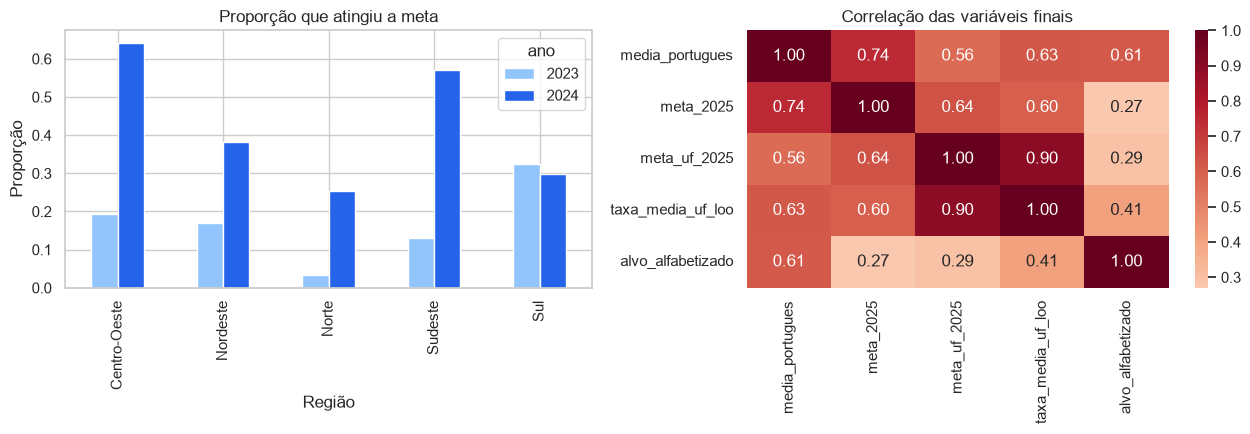

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
regional = df.groupby(["ano", "regiao"])["alvo_alfabetizado"].mean().unstack(0)
regional.plot.bar(ax=axes[0], color=["#93c5fd", "#2563eb"])
axes[0].set(title="Proporção que atingiu a meta", xlabel="Região", ylabel="Proporção")
cols = ["media_portugues", "meta_2025", "meta_uf_2025",
        "taxa_media_uf_loo", "alvo_alfabetizado"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[1])
axes[1].set_title("Correlação das variáveis finais")
plt.tight_layout()
plt.show()

## Hipóteses para a modelagem

1. Maior proficiência em Português está associada a maior chance de atingir a meta.
2. O contexto estadual captura desigualdades territoriais relevantes.
3. O salto da prevalência do alvo entre 2023 e 2024 pode reduzir a generalização temporal.
4. As associações não devem ser interpretadas como efeitos causais.